In [1]:
%matplotlib inline

# *lkprf* Aperture tutorial

## Authors
Rebekah Hounsell & Jorge Martinez-Palomera -- TESS Science Support Center

## Tutorial Goals

This tutorial is a follow on from the lkprf TPF example tutorial. It demostrates how a user can calculate an aperture for an object of interest using knowledge of its PRF. 

There are three kinds of aperture that we will implement:

- **Simple**: This computes that aperture that covers the total light of the targets PRF. This is a very simple aperture which should only be used for bright isolated stars. The user determines the level of target flux to be included within the aperture using a completeness metric.
- **SNR**: This aperture is calculated using a measurement of the target flux and the noise (detector noise and background contamination). In this method the PRF is computed for the target and for other contaminating stars within the surrounding region. The cumulative signal to noise is then calculated for the target and the optimal SNR as adding pixels is derived. This is close to SPOC algorithm to define SNR-optimal apertures, see [Smith et al. 2016](https://iopscience.iop.org/article/10.1088/1538-3873/128/970/124501).
- **Balanced**: This aperture is calculated based on the level of crowding acceptable to the user and the level of flux to be excluded. It has two input parameters, the flux fraction and the crowding fraction.

# Why is it important to select your aperture carefully?

When a planet transits its host star, it blocks a small fraction of the star's light. The observed dip in brightness, or transit depth, is used to determine the planet's size. However, if other stars are included in the aperture, the measured light comes from multiple sources and as such the measured transit depth inaccurate or "diluted". 

This dilution can be calculated via the following equation:

$$
D_i = \frac{F_{target}}{F_{target} + F_{contamination}}
$$

Where a dilution factor of 1 implies no contaminating sources and less than one indicates contamination. This metric is also called **CROWDSAP** in the mission TPFs and LCFs, referrring to the crowding within the aperture.

An example of all three apertures and their calculated dilution factors are shown below, first for a bright isolated source, AU Mic, and then a faint crowded source TIC 120916706.

### Importing packages

In this notebook we will utilize basic packages such as numpy and matplotlib, and more advanced astronomy packages such as astropy, lightkurve, lksearch, and of course lkprf.

In [2]:
import numpy as np

import matplotlib.pyplot as plt

import lkprf
import lkprf.aperture as aper
import lksearch
from lksearch.catalogsearch import query_region

import lightkurve as lk

from astropy.wcs import WCS
from astropy.io import fits
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord
from astropy.visualization import simple_norm

import pandas as pd

/Users/jimartin/miniforge3/envs/tess-now/lib/python3.10/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


### Defining a simple function

Much of this tutorial depends on deriving fundamental information from the header of the DataCube. This includes WCS infomration which will be used to convert object R.A and Dec values into x, y pixel positions such that a PRF model can be created. To enable this we have defined the following `get_surronding_objects` function.

In [3]:
def get_surrounding_objects(
    hdulist,
    catalog: str = "tic",
    pixel_size: float = 21.0,
    radius: float = None,
    output_epoch: Time = Time.now(),
    magnitude_limit: float = 15,
):
    # Get the WCS information
    wcs = WCS(hdulist[2].header)

    # Get the x, y origin pixel values
    origin_row = hdulist[1].header["2CRV4P"]
    origin_col = hdulist[1].header["1CRV4P"]

    # Get the shape of the tpf
    shape = hdulist[1].data["FLUX"].shape[1:]

    # Get the ra and dec of the target
    ra = hdulist[0].header["RA_OBJ"]
    dec = hdulist[0].header["DEC_OBJ"]

    radius = (np.round(max(shape) / 2) - 1) * pixel_size * u.arcsec

    # Allowed catalogs
    allowed_catalogs = ["tic", "kic", "epic", "gaiadr3"]

    # quary catalog
    if catalog in allowed_catalogs:
        surronding_objects = query_region(
            SkyCoord(ra=ra, dec=dec, unit="deg"),
            output_epoch=output_epoch,
            catalog=catalog,
            radius=radius,
            magnitude_limit=magnitude_limit,
        )

    else:
        print("Allowed catalogs are 'tic','kic','epic','gaiadr3'")

    # remove non-valid rows
    df_cleaned = surronding_objects.dropna(subset=["RA"]).reset_index(drop=True)

    # convert radec coords into pixel column and row
    df_cleaned["column"], df_cleaned["row"] = wcs.world_to_pixel(
        SkyCoord(df_cleaned["RA"].values, df_cleaned["Dec"].values, unit="deg")
    )
    # add cutout origin
    df_cleaned["column"] += origin_col
    df_cleaned["row"] += origin_row

    return df_cleaned, (origin_row, origin_col)

## Step 1: Get a the TPF
We will start by getting the Target Pixel File for a relatively isolated (low contamination) star, AU Mic. We limit the search using pipeline='SPOC', which restricts the search results to files produced by the mission pipeline. 

In [4]:
tpf_bright_search = lksearch.TESSSearch("Au Mic", pipeline="SPOC").cubedata
tpf_bright_search

,target_name,pipeline,mission,sector,exptime,distance,year,description
0,441420236,SPOC,TESS,1,120.0,0.0,2018,Target pixel files
1,441420236,SPOC,TESS,27,20.0,0.0,2020,Target pixel files
2,441420236,SPOC,TESS,27,120.0,0.0,2020,Target pixel files
3,441420236,SPOC,TESS,95,20.0,0.0,2025,Target pixel files
4,441420236,SPOC,TESS,95,120.0,0.0,2025,Target pixel files


The search result contains a table showing all of the observations of the target for which SPOC data is available to download. The exptime column indicates the observing cadence by TESS. 

As we know from the previous tutorials the TPF will be different for this target for every observing sector, as the target will fall on different pixels and different camera and CCDs. Let's just pick a single sector to model. In the download command below, we specify the 1st element of the table, corresponding to the 20-second cadence TPF from sector 27.

In [5]:
tpf_bright = tpf_bright_search[1].download()
tpf_bright

,Local Path,Status,Message,URL
0,/Users/jimartin/.lksearch/cache/mastDownload/T...,COMPLETE,None,None


We now have our dataframe containing the local file path it is downloaded to.  However, it does not read it in to a lightkurve object. We will read it in using the fits file handling package in astropy. If you need a refresher on fits file handling, you can see this [astropy tutorial](https://learn.astropy.org/tutorials/FITS-images.html). 

In [6]:
tess_hdulist = fits.open(tpf_bright["Local Path"].values[0])
tess_hdulist.info()

Filename: /Users/jimartin/.lksearch/cache/mastDownload/TESS/tess2020186164531-s0027-0000000441420236-0189-a_fast/tess2020186164531-s0027-0000000441420236-0189-a_fast-tp.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      44   ()      
  1  PIXELS        1 BinTableHDU    248   105285R x 11C   [D, E, J, 143J, 143E, 143E, 143E, 143E, J, E, E]   
  2  APERTURE      1 ImageHDU        49   (11, 13)   int32   
  3  TARGET COSMIC RAY    1 BinTableHDU     27   55863R x 4C   [J, I, I, E]   


## Step 2: Initializing a PRF model

Now that we have our file, we can set up our PRF model. 
To initiate a PRF object, we need to know which camera and CCD (TESS) or channel (Kepler) the target is on. We also can optionally provide the observing Sector for TESS. This is because two sets of PRF engineering models were produced for TESS. The first models were made during commissioning and are used for the early Sectors (Sectors 1-3). The commissioning observations were re-run after Sector 3, and these files can be used for subsequent TESS sectors. If the sector is not specified, the models produced for Sectors 4 onwards are used.

In [7]:
camera = tess_hdulist[0].header["CAMERA"]
ccd = tess_hdulist[0].header["CCD"]
sector = tess_hdulist[0].header["SECTOR"]

cutout_shape = tess_hdulist[1].data["FLUX"].shape[1:]

# initialize the PRF object
prf_initial = lkprf.TESSPRF(camera=camera, ccd=ccd, sector=sector)
prf_initial

TESSPRF Object [Camera 1, CCD 3, Sector 27]

## Step 3: Searching for objects in the surronding region

Now we want to assess what other objects might be in the surronding field. We can do this using the `get_surrounding_objects()` function defined above. This uses `lksearch` and some information from the header of our object, including it's WCS. We specify the limiting magnitude via the `magnitude_limit` input, we can also select the catalog we wish to search. 

In [8]:
# we use the mid-time of the sector for output catalog epoch
object_table, origin_pixel = get_surrounding_objects(
    tess_hdulist,
    catalog="tic",
    pixel_size=21,
    output_epoch=Time(
        np.nanmedian(tess_hdulist[1].data["TIME"]), scale="tdb", format="btjd"
    ),
    magnitude_limit=18.0,
)

This function has provided us with a list of objects within our region of interest, an array of TESS magnitudes for these objects, the x, y postion of the objects within the TPF, and the origin_row, origin_col for our TPF. We can view each as follows:

In [9]:
object_table

,ID,RA,Dec,Separation,Relative_Flux,pmRA,pmDE,TESSmag,Mass,Rad,Teff,logg,column,row
0,TIC 441420236,311.291598,-31.342954,0.000000,1.000000,281.424,-359.895,6.755000,0.662,0.698,NaN,4.5713,475.461274,1246.856072
1,TIC 441420238,311.298123,-31.341856,20.447568,0.000200,7.181,-7.003,16.004999,0.850,0.886,5070.0,4.4727,474.449594,1246.965824
2,TIC 441420240,311.284212,-31.344383,23.286850,0.000240,-3.239,-0.238,15.804000,0.650,0.681,3945.0,4.5842,476.617572,1246.763053
3,TIC 441420232,311.295342,-31.334027,34.137148,0.000172,18.273,-14.821,16.167000,0.650,0.729,4133.0,4.5258,474.389976,1245.526959
4,TIC 441420230,311.294049,-31.331422,42.193250,0.001037,11.049,-11.270,14.216000,1.040,1.123,5799.0,4.3544,474.423552,1245.031625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8,TIC 1992412623,311.291401,-31.363579,74.253149,0.004238,-15.717,-18.767,12.687000,1.100,1.167,5980.0,4.3452,476.709934,1250.307776
9,TIC 441420254,311.291723,-31.364892,78.979321,0.002004,-15.638,-18.905,13.500000,0.980,0.857,5571.0,4.5634,476.740810,1250.542657
10,TIC 441420231,311.267303,-31.331451,85.413861,0.000073,13.025,-17.765,17.101999,0.514,0.516,3479.0,4.7232,478.306529,1243.831493
11,TIC 441420225,311.269855,-31.326494,89.337941,0.000168,14.283,-0.974,16.191999,0.359,0.372,3498.0,4.8532,477.643174,1243.114712


We see the first row in the table is our target with $T_{mag} = 6.75$ while the rest of the background sources are fainter than $T_{mag} > 12.6$.

In [10]:
# pixel origin of the cutout
origin_pixel

(1240, 470)

## Step 4: Creating the 3D PRF model

We can now use the TESS magnitudes and x,y postions obtained above to construct our 3D PRF model data cube.

In [11]:
# lkprf evaluate function requires a list of tuples for the source location.
prf_mod = prf_initial.evaluate(
    targets=[(x[0], x[1]) for x in object_table[["row", "column"]].values],
    origin=origin_pixel,
    shape=cutout_shape,
)

We now have a model PRF's for our object and 12 other objects in the field that can be contaminating our source. Lets plot the target, and its PRF model. Red crosses mark the position of all targets within the field.

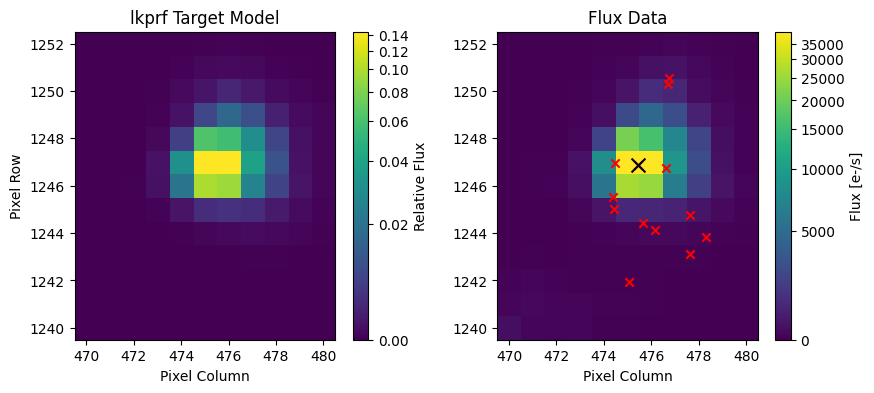

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

extent=(
        origin_pixel[1] - 0.5,
        origin_pixel[1] + cutout_shape[1] - 0.5,
        origin_pixel[0] - 0.5,
        origin_pixel[0] + cutout_shape[0] - 0.5,
    )

model = axs[0].imshow(
    prf_mod[0, :, :],
    norm=simple_norm(prf_mod[0, :, :], "asinh", percent=98),
    origin="lower",
    extent=extent,
)
axs[0].set_title("lkprf Target Model")
fig.colorbar(model, ax=axs[0], label="Relative Flux")

# Plot the real data. We randomly select the 100th observation from the TPF data cube
image = tess_hdulist[1].data["FLUX"][100, :, :]
data = axs[1].imshow(
    image,
    norm=simple_norm(image, "asinh", percent=98),
    origin="lower",
    extent=extent,
)
axs[1].set_title("Flux Data")
axs[1].scatter(
    object_table.column,
    object_table.row,
    color="red",
    marker="x",
)
axs[1].scatter(
    object_table.column[0],
    object_table.row[0],
    color="k",
    marker="x",
    s=100,
)
fig.colorbar(data, ax=axs[1], label="Flux [e-/s]")
axs[0].set_ylabel("Pixel Row")
axs[0].set_xlabel("Pixel Column")
axs[1].set_xlabel("Pixel Column")

plt.show()


## Step 5: Creating the apertures and calculating the dilution factor

Now lets generate the three possible apertures for our object using the `get_aperture` function and see what is selected. 

In [13]:
simple_ap = prf_initial.get_aperture(
    aperture_type="simple", completeness=0.99, source_mag=object_table.TESSmag.values,
)
di_simple = prf_initial.aperture_model.compute_CROWDSAP(simple_ap)
print("Dilution factor for simple aperture:", di_simple)

Dilution factor for simple aperture: 0.9930269016243994


In [14]:
# to compute SNR that account for instrument noise, we take the read noise for
# the CCD output of this source, which is based in the column pixel value (480<512) 
# read output "A" and we compute the quantization noise using the number of reads 
# in the exposure (10), the CCD well depth (1.5e5 e-) and analog-to-digital conversion 
# bits (16).
quant_noise = np.sqrt(tess_hdulist[1].header["NREADOUT"]/12) * (1.5e5 / 2 ** (16 - 1)) ** 2
read_noise = tess_hdulist[1].header["READNOIA"]

snr_ap = prf_initial.get_aperture(
    aperture_type="snr",
    completeness=0.99,
    source_mag=object_table.TESSmag.values,
    read_noise=read_noise,
    quantization_noise=quant_noise,
)
di_snr = prf_initial.aperture_model.compute_CROWDSAP(snr_ap)
print("Dilution factor for SNR-optimal aperture:", di_snr)

Dilution factor for SNR-optimal aperture: 0.9954679896872146


In [15]:
balanced_ap = prf_initial.get_aperture(
    aperture_type="balanced",
    crowding_metric=0.8,
    fluxfrac_metric=0.9,
    source_mag=object_table.TESSmag.values,
)
di_balanced = prf_initial.aperture_model.compute_CROWDSAP(balanced_ap)
print("Dilution factor for balanced aperture:", di_balanced)

Dilution factor for balanced aperture: 0.9987099426401234


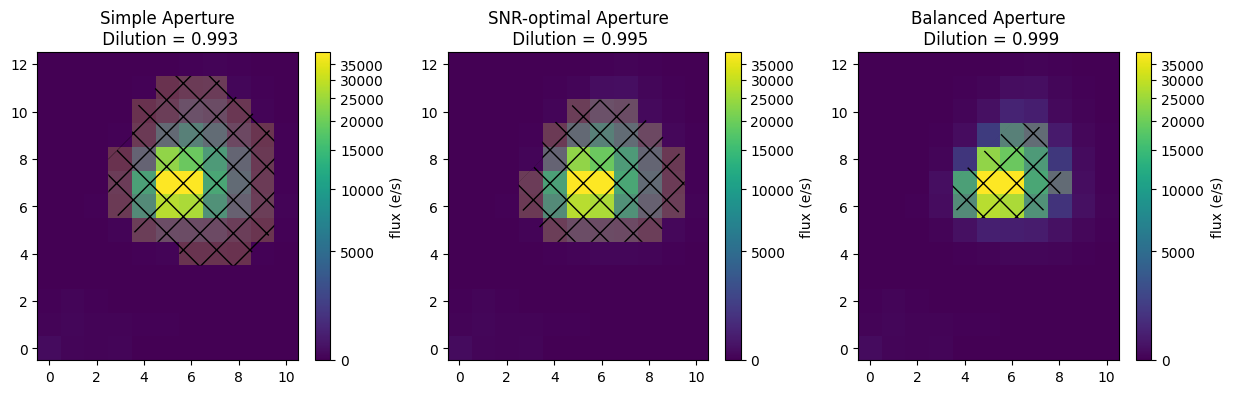

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

image = tess_hdulist[1].data["FLUX"][100, :, :]
norm = simple_norm(image, "asinh", percent=98)

data = axs[0].imshow(image, origin="lower", norm=norm)
axs[0].imshow(simple_ap, alpha=0.2, origin="lower")
axs[0].contourf(
    simple_ap,
    levels=[0.5, 1.5],  # Contour levels to isolate the True values
    hatches=["", "x"],  # First for False, second for True
    colors="none",  # Use 'none' for colors to ensure transparency
    extend="both",  # This is important for handling out-of-range values
)
axs[0].set_title(f"Simple Aperture\n Dilution = {di_simple:.3f}")
fig.colorbar(data, ax=axs[0], label="flux (e/s)")

data = axs[1].imshow(image, origin="lower", norm=norm)
axs[1].imshow(snr_ap, alpha=0.2, origin="lower")
axs[1].contourf(
    snr_ap,
    levels=[0.5, 1.5],  # Contour levels to isolate the True values
    hatches=["", "x"],  # First for False, second for True
    colors="none",  # Use 'none' for colors to ensure transparency
    extend="both",  # This is important for handling out-of-range values
)
axs[1].set_title(f"SNR-optimal Aperture\n Dilution = {di_snr:.3f}")
fig.colorbar(data, ax=axs[1], label="flux (e/s)")

data = axs[2].imshow(image, origin="lower", norm=norm)
axs[2].imshow(balanced_ap, alpha=0.2, origin="lower")
axs[2].contourf(
    balanced_ap,
    levels=[0.5, 1.5],  # Contour levels to isolate the True values
    hatches=["", "x"],  # First for False, second for True
    colors="none",  # Use 'none' for colors to ensure transparency
    extend="both",  # This is important for handling out-of-range values
)
axs[2].set_title(f"Balanced Aperture\n Dilution = {di_balanced:.3f}")
fig.colorbar(data, ax=axs[2], label="flux (e/s)")

plt.show()

As we can see the simple aperture with 99% completeness is quite large, the SNR-optimal aperture is smaller and only consider pixels that add SNR to the final aperture. The final balanced aperture tries to get 90% of the target flux while only allowing 20% contamination from surrounding stars, but because this is an isolated target (with background contamination at least 6 magnitude fainter), the resulting aperture is almost clean. 

## Step 6: Testing on a crowded object

Now lets repeat the experiment with a much fainter object, TIC 120916706.

In [17]:
tpf_faint_search = lksearch.TESSSearch("TIC 120916706", pipeline="SPOC").cubedata
tpf_faint_search

,target_name,pipeline,mission,sector,exptime,distance,year,description
0,120916706,SPOC,TESS,3,120.0,0.0,2018,Target pixel files
1,120916706,SPOC,TESS,30,120.0,0.0,2020,Target pixel files
2,120916706,SPOC,TESS,97,20.0,0.0,2025,Target pixel files
3,120916706,SPOC,TESS,97,120.0,0.0,2025,Target pixel files


In [18]:
tpf_faint = tpf_faint_search[0].download()
tess_hdulist_faint = fits.open(tpf_faint["Local Path"].values[0])

Let's repeat the process of query the TIC catalog to see what sources are in the field and how crowded it is.

To calculate an aperture we must take the surronding objects into accont and be very selective about what pixels we include in our aperture mask. To do this we first gather information about the location of our target, and the surronding objects.  

In [19]:
camera_faint = tess_hdulist_faint[0].header["CAMERA"]
ccd_faint = tess_hdulist_faint[0].header["CCD"]
sector_faint = tess_hdulist_faint[0].header["SECTOR"]

shape_faint = tess_hdulist_faint[1].data["FLUX"].shape[1:]

# initialize the PRF object
prf_initial_faint = lkprf.TESSPRF(
    camera=camera_faint, ccd=ccd_faint, sector=sector_faint
)

Now examine objects within the surronding region.

In [20]:
# we use the mid-time of the sector for output catalog epoch
object_table_faint, origin_pixel_faint = get_surrounding_objects(
    tess_hdulist_faint,
    catalog="tic",
    pixel_size=21,
    output_epoch=Time(
        np.nanmedian(tess_hdulist_faint[1].data["TIME"]), scale="tdb", format="btjd"
    ),
    magnitude_limit=18.0,
)
object_table_faint

,ID,RA,Dec,Separation,Relative_Flux,pmRA,pmDE,TESSmag,Mass,Rad,Teff,logg,column,row
0,TIC 120916706,37.108307,-25.097319,0.000000,1.000000,30.333,10.142,15.620000,0.436,0.440,3423.0,4.7907,252.157005,1439.803989
1,TIC 120916709,37.097680,-25.087649,49.116859,1.221237,-0.417,8.098,15.403000,0.760,0.652,4721.0,4.6905,252.669278,1437.467311
2,TIC 120916710,37.114370,-25.083544,53.387167,1.088429,8.141,-1.314,15.528000,1.000,0.979,5625.0,4.4562,249.953043,1438.238290
3,TIC 120916705,37.130246,-25.101775,73.298359,0.281838,6.393,-5.949,16.995001,0.650,0.961,4130.0,4.2859,249.563473,1442.297816
4,TIC 120916707,37.135225,-25.091441,90.272855,0.976338,62.346,-1.405,15.646000,1.030,0.577,5741.0,4.9287,247.850344,1441.159277
5,TIC 120916704,37.124017,-25.119018,93.405631,0.561823,5.918,-5.036,16.246000,0.720,0.823,4567.0,4.4645,252.134042,1444.370445


There are lots of similarly bright objects in this region, we must model these.

In [21]:
# lkprf evaluate function requires a list of tuples for the source location.
prf_mod_faint = prf_initial_faint.evaluate(
    targets=[(x[0], x[1]) for x in object_table_faint[["row", "column"]].values],
    origin=origin_pixel_faint,
    shape=shape_faint,
)

We can plot our target PRF model and data and we can examine the relative flux scale to see how faint this object is with respect to other stars in the field.

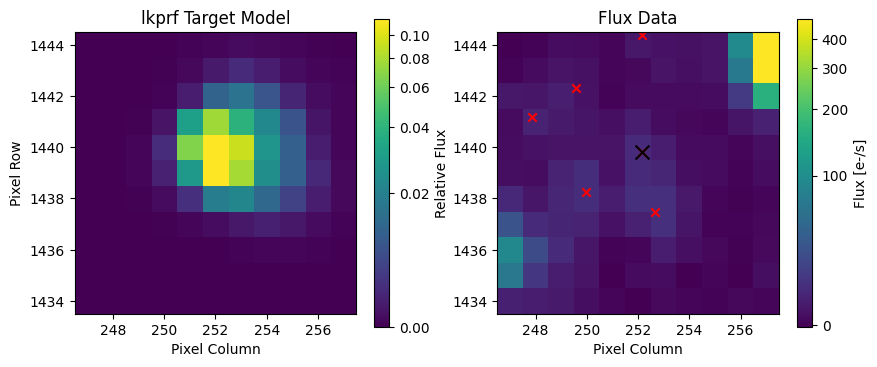

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

extent = (
    origin_pixel_faint[1] - 0.5,
    origin_pixel_faint[1] + shape_faint[1] - 0.5,
    origin_pixel_faint[0] - 0.5,
    origin_pixel_faint[0] + shape_faint[0] - 0.5,
)

model = axs[0].imshow(
    prf_mod_faint[0, :, :],
    norm=simple_norm(prf_mod_faint[0, :, :], "asinh", percent=98),
    origin="lower",
    extent=extent,
)
axs[0].set_title("lkprf Target Model")
fig.colorbar(model, ax=axs[0], label="Relative Flux")

# Plot the real data. We randomly select the 100th observation from the TPF data cube
image = tess_hdulist_faint[1].data["FLUX"][100, :, :]
data = axs[1].imshow(
    image,
    norm=simple_norm(image, "asinh", percent=98),
    origin="lower",
    extent=extent,
)
axs[1].set_title("Flux Data")
axs[1].scatter(
    object_table_faint.column,
    object_table_faint.row,
    color="red",
    marker="x",
)
axs[1].scatter(
    object_table_faint.column[0],
    object_table_faint.row[0],
    color="k",
    marker="x",
    s=100,
)
fig.colorbar(data, ax=axs[1], label="Flux [e-/s]")
axs[0].set_ylabel("Pixel Row")
axs[0].set_xlabel("Pixel Column")
axs[1].set_xlabel("Pixel Column")

plt.show()


Now lets compute our apertures based on the PRF. 

In [23]:
simple_ap_faint = prf_initial_faint.get_aperture(
    aperture_type="simple",
    completeness=0.99,
    source_mag=object_table_faint.TESSmag.values,
)
di_simple_faint = prf_initial_faint.aperture_model.compute_CROWDSAP(simple_ap_faint)
print("Dilution factor for simple aperture:", di_simple_faint)

quant_noise = (
    np.sqrt(tess_hdulist_faint[1].header["NREADOUT"] / 12) * (1.5e5 / 2 ** (16 - 1)) ** 2
)
read_noise = tess_hdulist_faint[1].header["READNOIA"]

snr_ap_faint = prf_initial_faint.get_aperture(
    aperture_type="snr",
    completeness=0.99,
    source_mag=object_table_faint.TESSmag.values,
    read_noise=read_noise,
    quantization_noise=quant_noise,
)
di_snr_faint = prf_initial_faint.aperture_model.compute_CROWDSAP(snr_ap_faint)
print("Dilution factor for SNR-optimal aperture:", di_snr_faint)

balanced_ap_faint = prf_initial_faint.get_aperture(
    aperture_type="balanced",
    crowding_metric=0.8,
    fluxfrac_metric=0.9,
    source_mag=object_table_faint.TESSmag.values,
)
di_balanced_faint = prf_initial_faint.aperture_model.compute_CROWDSAP(balanced_ap_faint)
print("Dilution factor for balanced aperture:", di_balanced_faint)

Dilution factor for simple aperture: 0.3289478783433921
Dilution factor for SNR-optimal aperture: 0.748187684409233
Dilution factor for balanced aperture: 0.88832520919988


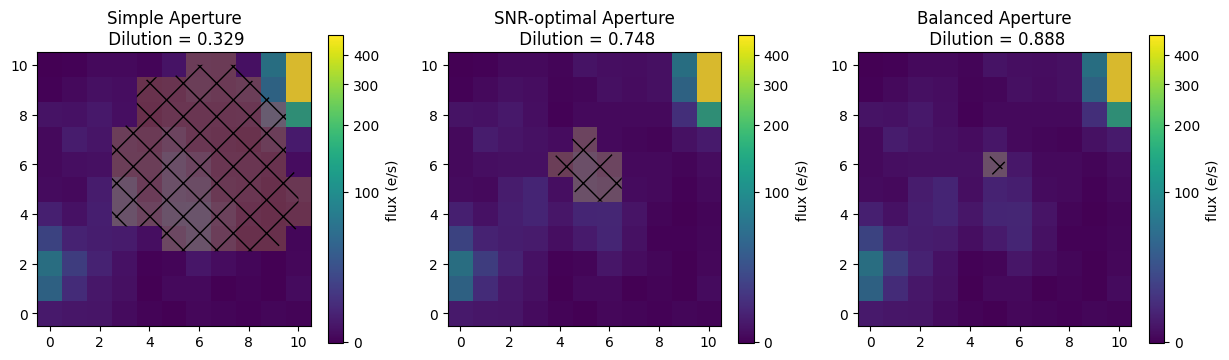

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

image = tess_hdulist_faint[1].data["FLUX"][100, :, :]
norm=simple_norm(image, "asinh", percent=98)

data = axs[0].imshow(image, norm=norm, origin="lower")
axs[0].imshow(simple_ap_faint, alpha=0.2, origin="lower")
axs[0].contourf(
    simple_ap_faint,
    levels=[0.5, 1.5],  # Contour levels to isolate the True values
    hatches=["", "x"],  # First for False, second for True
    colors="none",  # Use 'none' for colors to ensure transparency
    extend="both",  # This is important for handling out-of-range values
)
axs[0].set_title(f"Simple Aperture\n Dilution = {di_simple_faint:.3f}")
fig.colorbar(data, ax=axs[0], label="flux (e/s)")

data = axs[1].imshow(image, norm=norm, origin="lower")
axs[1].imshow(snr_ap_faint, alpha=0.2, origin="lower")
axs[1].contourf(
    snr_ap_faint,
    levels=[0.5, 1.5],  # Contour levels to isolate the True values
    hatches=["", "x"],  # First for False, second for True
    colors="none",  # Use 'none' for colors to ensure transparency
    extend="both",  # This is important for handling out-of-range values
)
axs[1].set_title(f"SNR-optimal Aperture\n Dilution = {di_snr_faint:.3f}")
fig.colorbar(data, ax=axs[1], label="flux (e/s)")

data = axs[2].imshow(image, norm=norm, origin="lower")
axs[2].imshow(balanced_ap_faint, alpha=0.2, origin="lower")
axs[2].contourf(
    balanced_ap_faint,
    levels=[0.5, 1.5],  # Contour levels to isolate the True values
    hatches=["", "x"],  # First for False, second for True
    colors="none",  # Use 'none' for colors to ensure transparency
    extend="both",  # This is important for handling out-of-range values
)
axs[2].set_title(f"Balanced Aperture\n Dilution = {di_balanced_faint:.3f}")
fig.colorbar(data, ax=axs[2], label="flux (e/s)")

plt.show()


We can see here that the SNR and Balanced apertures are probably the best ones here as we want to reduce contamination while maximizing flux contained. 

Additionally, the `Aperture` module has helping functions to compute the flux fraction and crowding (dilution) for a given aperture. Let's use the SNR-optimal aperture from our example above.

In [27]:
print(f"CROWDSAP = {prf_initial_faint.aperture_model.compute_CROWDSAP(snr_ap_faint):.4f}")
print(f"FLFRCSAP = {prf_initial_faint.aperture_model.compute_FLFRCSAP(snr_ap_faint):.4f}")

CROWDSAP = 0.7482
FLFRCSAP = 0.6226
